# Generating and reading a mesh

In [1]:
import numpy as np
import matplotlib.tri as tri
import matplotlib.pyplot as plt

def generate_scalar_field(field, axis=None):
    if axis is None:
        field = np.linalg.norm(field, axis=1)
    else:
        field = field[:, axis]
    return field

def plotMesh(coords, connectivity, nodal_field=None, elemental_field=None, **kwargs):
    triangles = tri.Triangulation(coords[:, 0], coords[:, 1], connectivity)
    plt.axes().set_aspect('equal')
    if nodal_field is not None:
        nodal_field = nodal_field.reshape(points.shape[0], nodal_field.size//points.shape[0])
        nodal_field = generate_scalar_field(nodal_field, **kwargs)
        contour = plt.tricontourf(triangles, nodal_field)
        plt.colorbar(contour)
    if elemental_field is not None:
        elemental_field = elemental_field.reshape(connectivity.shape[0], elemental_field.size//connectivity.shape[0])
        elemental_field = generate_scalar_field(elemental_field, **kwargs)
        contour = plt.tripcolor(triangles, elemental_field)
        plt.colorbar(contour)

    t = plt.triplot(triangles, '--', lw=.8)

In [2]:
import meshio
import numpy as np

def readMesh(filename, element_type='triangle'):
    mesh = meshio.read(filename)
    nodes = mesh.points[:, :2]
    elems = []
    for c in mesh.cells:
        if c.type != element_type:
            continue
        elems.append(np.array([i for i in c.data]))
    elems = np.vstack(elems)
    return nodes, elems

In [3]:
import subprocess, os

def meshGeo(filename, dim=2, order=1):
    ret = subprocess.run(f"gmsh -2 -order 1 -o tmp.msh {filename}", shell=True)
    if ret.returncode:
        print("Beware, gmsh could not run: mesh is not generated")
    else:
        print("Mesh generated")
        mesh = readMesh('tmp.msh')
        os.remove('tmp.msh')
        return mesh
    return None

Mesh generated


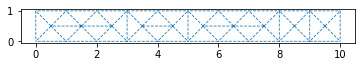

In [4]:
geo_file = """
lc = DefineNumber[ 1, Name "Parameters/lc" ];
Point(1) = {0, 0, 0, lc};
Point(2) = {5, 0, 0, lc};
Point(3) = {5, 1, 0, lc};
Point(4) = {0, 1, 0, lc};
Point(5) = {10, 0, 0, lc};
Point(6) = {10, 1, 0, lc};

Line(1) = {1, 2};
Line(2) = {2, 3};
Line(3) = {3, 4};
Line(4) = {4, 1};
Line(5) = {2, 5};
Line(6) = {5, 6};
Line(7) = {6, 3};
Line Loop(8) = {3, 4, 1, 2};
Line Loop(9) = {5, 6, 7, -2};
Plane Surface(10) = {8};
Plane Surface(11) = {9};
"""

open("poutre.geo", 'w').write(geo_file)

points, conn = meshGeo('poutre.geo', order=1)
plotMesh(points, conn)

# Plotting nodal data

## plotting the norm of the field

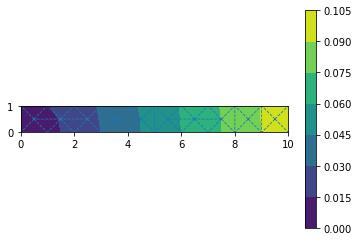

In [5]:
u = points*0.01 # could be any displacement field
plotMesh(points, conn, nodal_field=u)

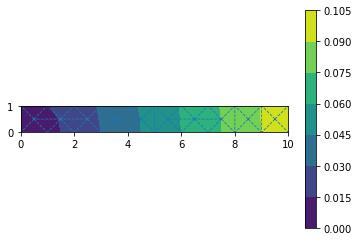

In [6]:
plotMesh(points, conn, nodal_field=u.flatten()) # does not matter if it has the same shape as the stiffness matrix

## plotting a specific component

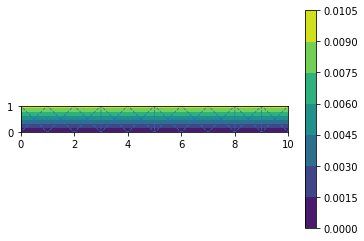

In [7]:
plotMesh(points, conn, nodal_field=u, axis=1) # y-direction of u

# Plotting element data

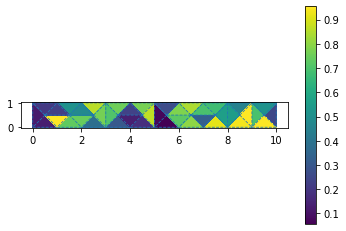

In [8]:
stress = np.random.random((conn.shape[0], 3))          # stress contains 3 values s_xx s_yy s_xy
plotMesh(points, conn, elemental_field=stress, axis=1) # sigma_yy direction of stress

# Saving figure to pdf/png file

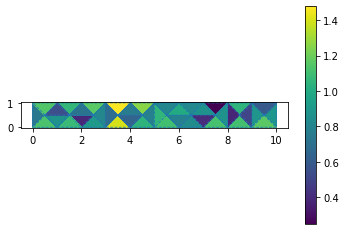

In [9]:
stress = np.random.random((conn.shape[0], 3))          # stress contains 3 values s_xx s_yy s_xy
plotMesh(points, conn, elemental_field=stress)         # stress norm
plt.savefig('sample.pdf') # for pdf
# plt.savefig('sample.png') # for png or any other image format

# Saving data to csv file

In [10]:
# documentation at https://numpy.org/doc/stable/reference/generated/numpy.savetxt.html
np.savetxt('stress.csv', stress, delimiter=',')

# Reading data from csv file

In [11]:
# documentation at https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html
np.loadtxt('stress.csv', delimiter=',')

array([[0.68621711, 0.24605745, 0.54372044],
       [0.26450517, 0.98925936, 0.95297484],
       [0.68686927, 0.15621316, 0.77273737],
       [0.43908732, 0.51110951, 0.31091418],
       [0.34121053, 0.18297347, 0.06467141],
       [0.59265675, 0.77572642, 0.41995014],
       [0.44103117, 0.53018278, 0.91297386],
       [0.58856325, 0.43089152, 0.86104378],
       [0.83072417, 0.89534085, 0.83283513],
       [0.89711285, 0.11917961, 0.87627323],
       [0.88873726, 0.24755424, 0.70719772],
       [0.08339304, 0.30155775, 0.71557148],
       [0.20509834, 0.7178891 , 0.34201234],
       [0.62442479, 0.27642975, 0.04536617],
       [0.25738446, 0.51021527, 0.4412716 ],
       [0.42100813, 0.1720944 , 0.98152626],
       [0.10761071, 0.46149757, 0.73675516],
       [0.64659   , 0.13981135, 0.36293816],
       [0.39671578, 0.00687813, 0.50483578],
       [0.10871256, 0.46450276, 0.26795375],
       [0.74232647, 0.2976027 , 0.2156507 ],
       [0.4320398 , 0.64754364, 0.71082648],
       [0.

# Dynamics integration

Voici un exemple de schémas d'intégration qui fonctionne avec des conditions aux bords en déplacement (Dirichlet) et des conditions aux bords en traction (Neumann)

```python
import scipy.sparse

nodes = points
V = np.zeros_like(nodes)  # velocities
A = np.zeros_like(nodes)  # accelerations
U = np.zeros_like(nodes)      # displacements
F = np.zeros_like(nodes)      # external forces

# make the matrices sparse
K = scipy.sparse.csr_matrix(K)
M = scipy.sparse.csr_matrix(M)

nstep = 1000
for s in range(0, nsteps):
    _time = s*dt
    V_star = V + dt/2*A
    U[:] = U + dt*V_star
    # enforce displacement boundary conditions by changing U
    U[blocked] = disp(_time)
    # enforce tractions by chaning F
    F[:] = tractions(_time)

    A[:] = scipy.sparse.linalg.spsolve(M, -K@U+F) 
    V[:] = V_star + dt/2*A
    
    # enforce consistant boundary conditions by changing V
    V[blocked] = disp_derivative(_time) # time derivative == velocity
```